In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:

#C:\Users\bda\Desktop\261100660031\AML_LAB\Lab_5\Salary_Data.csv
df = pd.read_csv(r"D:\AIML_MSIS\Applied Machine Learning\Lab_Assignment\AML-LAB-main\LAB 5\Salary_Data.csv")

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [6]:
x = df[["YearsExperience"]]
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [7]:
y = df["Salary"]
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 42)

In [9]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [10]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  25324.33537924433
Slope :  9426.038769074834


In [11]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  4956.5232614449005
MSE       :  35301898.887134895
RMSE      :  5941.540110706558
R-squared :  0.9553063138044949


        #After ridge
        MAE       :  4973.600767464554
        MSE       :  35424098.508684516
        RMSE      :  5951.81472398835
        R-squared :  0.9551516039528745


C:\Users\SHASHWATH NAREN\AppData\Local\Temp\ipykernel_19388\1698129918.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


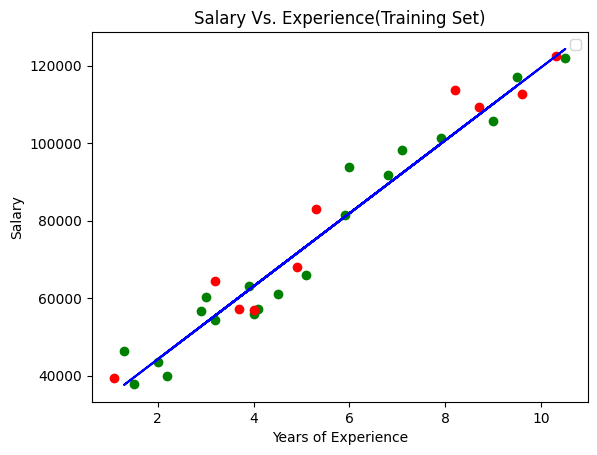

In [12]:
plt.scatter(x_train, y_train, color = 'green')
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, model.predict(x_train), color = 'blue')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Vs. Experience(Training Set)")
#plt.grid(True)
plt.legend()
plt.show()


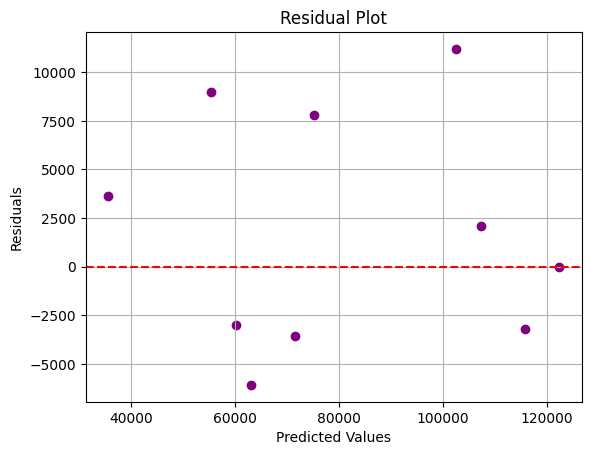

In [13]:
y_pred_test = model.predict(x_test)

residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

K-FOLD

In [14]:
np.random.seed(42)
expanded_indices = np.random.choice(df.index, size=100, replace=True)

x = df.loc[expanded_indices, ["YearsExperience"]].values

x = x + np.random.normal(0, 0.05, x.shape)

y = df.loc[expanded_indices, "Salary"].values
y = y + np.random.normal(0, 500, y.shape)


In [15]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score

k_values = [4, 5, 6]
test_sizes = [0.20, 0.25, 0.30]
results = []

for k in k_values:
    for test_size in test_sizes:
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)
        
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_scores = []
        
        for train_idx, val_idx in kf.split(x_train):
            x_fold_train, x_fold_val = x_train[train_idx], x_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
            fold_model = LinearRegression()
            fold_model.fit(x_fold_train, y_fold_train)
            
            y_fold_pred = fold_model.predict(x_fold_val)
            r2 = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(r2)
            
        results.append({
            "K (Folds)": k,
            "Test Size (%)": int(test_size * 100),
            "Fold Scores (R²)": [round(score, 4) for score in fold_scores],
            "Average R²": round(np.mean(fold_scores), 4)
        })


In [16]:
df_results = pd.DataFrame(results)
print("===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====")
df_results


===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====


,K (Folds),Test Size (%),Fold Scores (R²),Average R²
0,4,20,"[0.9586, 0.949, 0.9606, 0.9746]",0.9607
1,4,25,"[0.9649, 0.9634, 0.9576, 0.9411]",0.9567
2,4,30,"[0.9392, 0.9728, 0.9658, 0.9555]",0.9583
3,5,20,"[0.9556, 0.9249, 0.9665, 0.9613, 0.9795]",0.9576
4,5,25,"[0.9541, 0.9777, 0.9419, 0.9588, 0.9428]",0.9551
5,5,30,"[0.9324, 0.9574, 0.9385, 0.9809, 0.9448]",0.9508
6,6,20,"[0.9638, 0.8965, 0.9743, 0.9665, 0.9296, 0.9822]",0.9522
7,6,25,"[0.9376, 0.9841, 0.9542, 0.9493, 0.932, 0.9563]",0.9522
8,6,30,"[0.9269, 0.957, 0.9689, 0.9572, 0.9737, 0.9405]",0.9540


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

final_model = LinearRegression()
final_model.fit(x_train, y_train)
y_pred = final_model.predict(x_test)

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  4864.682302028956
MSE       :  32215197.8300407
RMSE      :  5675.843358483451
R-squared :  0.9514316465957756


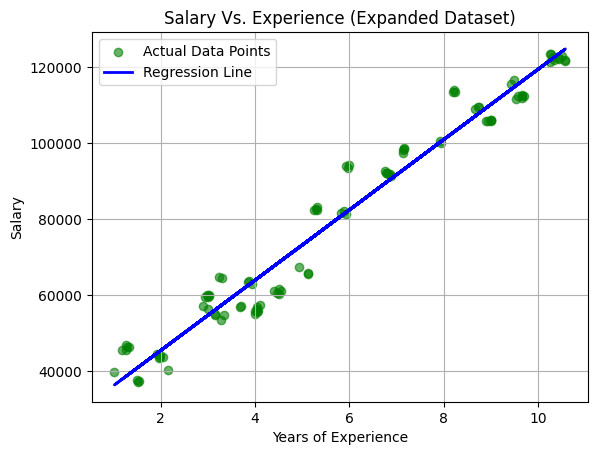

In [18]:
y_plot_line = final_model.predict(x)
plt.scatter(x, y, color="green", alpha=0.6, label="Actual Data Points")
plt.plot(x, y_plot_line, color="blue", linewidth=2, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Vs. Experience (Expanded Dataset)")
plt.grid(True)
plt.legend()
plt.show()

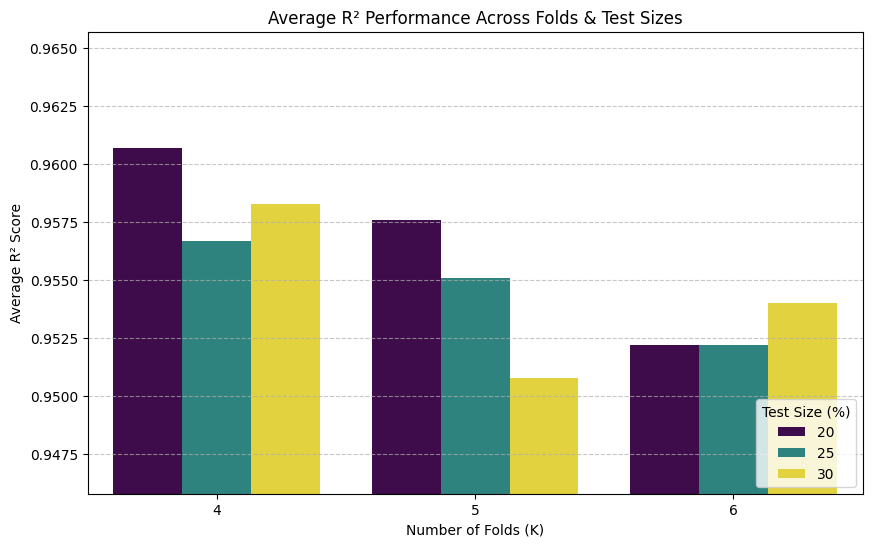

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="K (Folds)", y="Average R²", hue="Test Size (%)", palette="viridis")

plt.title("Average R² Performance Across Folds & Test Sizes")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Average R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_score = df_results["Average R²"].min()
max_score = df_results["Average R²"].max()
plt.ylim(min_score - 0.005, max_score + 0.005)

plt.legend(title="Test Size (%)", loc="lower right")
plt.show()
